In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP
import sklearn
import seaborn as sns
import h5py
from process import SpaHDSRL
import warnings
warnings.filterwarnings('ignore')
random_seed = 20

In [ ]:
data_mat = h5py.File("./tutorial3/DBiT_Seq Mouse Embryo_RNA_Protein.h5", 'r')
df_data_RNA = np.array(data_mat['X_gene']).astype('float64')     # gene count matrix
df_data_protein = np.array(data_mat['X_protein']).astype('float64')  # protein count matrix
loc = np.array(data_mat['pos']).astype('float64') 
gene_names = list(data_mat['gene'])
gene_names = [gene.decode("utf-8") for gene in gene_names]
protein_names = list(data_mat['protein'])
protein_names = [protein.decode("utf-8") for protein in protein_names]
protein_names = [protein.split(".")[0] for protein in protein_names]

In [3]:
adata1 = sc.AnnData(df_data_RNA, dtype="float64")
adata1.index = gene_names
sc.pp.normalize_per_cell(adata1)
sc.pp.log1p(adata1)

adata2 = sc.AnnData(df_data_protein, dtype="float64")
adata2.index = protein_names
sc.pp.log1p(adata2)


adata1.obsm['spatial'] = np.array(loc)
adata1.obs['x_pos'] = np.array(loc)[:,0]
adata1.obs['y_pos'] = np.array(loc)[:,1]


adata2.obsm['spatial'] = np.array(loc)
adata2.obs['x_pos'] = np.array(loc)[:,0]
adata2.obs['y_pos'] = np.array(loc)[:,1]

In [4]:
adata1.var["gene_names"] = gene_names
adata2.var["protein_names"] = protein_names
adata1.var_names = gene_names
adata2.var_names = protein_names

In [ ]:
SpaHDSRL_result = SpaHDSRL(adata1=adata1,adata2=adata2)
SpaHDSRL_result.preprocessing_data(do_norm = True, do_log = True, n_neighbors = 10)
SpaHDSRL_result.train(spatial_regularization_strength=0.05, z_dim=50, 
         lr=1e-3, total_epoch=350, random_seed=random_seed, gpu=0, regularization_acceleration=True, edge_subset_sz=1000000, k_neighbors=10, gamma=0.05)

df_embedding = pd.DataFrame(SpaHDSRL_result.embedding)

Epoch 1/350, Loss: 1.400153398513794
Epoch 11/350, Loss: 1.3632527589797974
Epoch 21/350, Loss: 1.2654162645339966
Epoch 31/350, Loss: 1.1464864015579224
Epoch 41/350, Loss: 0.9734563231468201
Epoch 51/350, Loss: 0.940104067325592
Epoch 61/350, Loss: 0.5899916291236877
Epoch 71/350, Loss: 0.34280285239219666
Epoch 81/350, Loss: 0.23745448887348175
Epoch 91/350, Loss: 0.16722460091114044
Epoch 101/350, Loss: 0.5138633251190186
Epoch 111/350, Loss: 0.11004407703876495
Epoch 121/350, Loss: 0.21992529928684235
Epoch 131/350, Loss: 0.19498860836029053
Epoch 141/350, Loss: 0.0982624888420105
Epoch 151/350, Loss: 0.10147808492183685
Epoch 161/350, Loss: 0.051213882863521576
Epoch 171/350, Loss: 0.04172952100634575
Epoch 181/350, Loss: 0.04700895771384239
Epoch 191/350, Loss: 0.03616664931178093
Epoch 201/350, Loss: 0.030882233753800392
Epoch 211/350, Loss: 0.03040778823196888
Epoch 221/350, Loss: 0.025200912728905678
Epoch 231/350, Loss: 0.023077286779880524
Epoch 241/350, Loss: 0.02331196144

In [6]:
def screen_res(df_embedding, n_cluster = 5, res_s = 0.1, res_e = 1.0, step = 0.1):
    opt_res = res_s
    opt_clusters = n_cluster
    for res in np.arange(res_s,res_e,step):
        embedding_adata = sc.AnnData(df_embedding)
        sc.pp.neighbors(embedding_adata, n_neighbors=50, use_rep='X')
        sc.tl.leiden(embedding_adata, resolution=float(res))
        clusters = list(embedding_adata.obs["leiden"])
        cluster_num = len(np.unique(clusters))
        print('res = ' + str(round(res, 2)) + ', Cluster# = ' + str(cluster_num))
        if cluster_num == n_cluster:
            opt_res = res
            opt_clusters = clusters
    print('optimal res = ' + str(round(opt_res, 2)))
    return opt_res, opt_clusters

# Screening resolution that matches the given number of clusters 
opt_res_SpaHDSRL, opt_clusters_SpaHDSRL = screen_res(df_embedding,res_s = 0.5, res_e = 0.8, step = 0.02,n_cluster = 10)

res = 0.5, Cluster# = 8
res = 0.52, Cluster# = 9
res = 0.54, Cluster# = 8
res = 0.56, Cluster# = 9
res = 0.58, Cluster# = 11
res = 0.6, Cluster# = 10
res = 0.62, Cluster# = 9
res = 0.64, Cluster# = 11
res = 0.66, Cluster# = 10
res = 0.68, Cluster# = 11
res = 0.7, Cluster# = 11
res = 0.72, Cluster# = 12
res = 0.74, Cluster# = 12
res = 0.76, Cluster# = 12
res = 0.78, Cluster# = 12
res = 0.8, Cluster# = 11
optimal res = 0.66


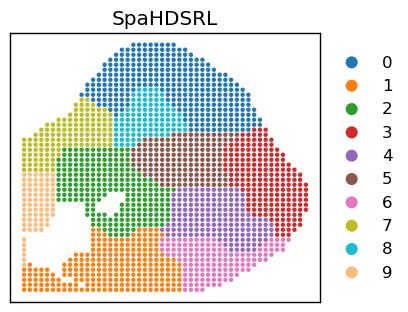

In [7]:
# Plotting figures
adata_new = adata1.copy()
adata_new.obs["Cluster_SpaHDSRL"] = opt_clusters_SpaHDSRL
adata_new.obs["Cluster_SpaHDSRL"]=adata_new.obs["Cluster_SpaHDSRL"].astype("category")

matplotlib.rcParams["font.size"] = 12.0
fig, axes = plt.subplots(1, 1, figsize=(4,3.5))
sz = 40
plot_color = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#bcbd22", "#17becf", "#ffbb78"
]
# plot_color=['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', \
#             '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3', '#808000', '#000075', '#000000', '#808080', '#ffffff', '#fffac8']

domains="Cluster_SpaHDSRL"
num_celltype=len(adata_new.obs[domains].unique())
adata_new.uns[domains+"_colors"]=list(plot_color[:num_celltype])
titles = "SpaHDSRL"
ax=sc.pl.scatter(adata_new,alpha=1,x="x_pos",y="y_pos",color=domains,title=titles ,color_map=plot_color,show=False,size=sz,ax = axes)

ax.axes.invert_yaxis()
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")

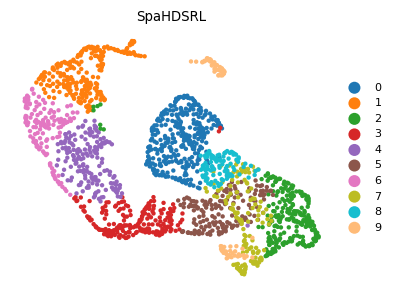

In [8]:
# UMAP visualization
umap_2d = UMAP(n_components=2, init='random', random_state=random_seed, min_dist = 0.3,n_neighbors=30)
umap_pos = umap_2d.fit_transform(df_embedding)
adata_new.obs['SpaHDSRL_umap_pos_x'] = umap_pos[:,0]
adata_new.obs['SpaHDSRL_umap_pos_y'] = umap_pos[:,1]

# Ploting figures
plot_color = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#bcbd22", "#17becf", "#ffbb78"
]
matplotlib.rcParams['font.size'] = 8.0
fig, axes = plt.subplots(1, 1, figsize=(4,3))
sz = 40
domains="Cluster_SpaHDSRL"
num_celltype=len(adata_new.obs[domains].unique())
adata_new.uns[domains+"_colors"]=list(plot_color[:num_celltype])
titles = 'SpaHDSRL'
ax=sc.pl.scatter(adata_new,alpha=1,x="SpaHDSRL_umap_pos_x",y="SpaHDSRL_umap_pos_y",color=domains,title=titles ,color_map=plot_color,show=False,size=sz,ax = axes)
ax.axis('off')
plt.tight_layout()